 # Pronosticos a series de tiempo tendencia y estacionalidad
En muchos procesos reales los datos no se comportan de manera estable ni aleatoria. Por el contrario, suelen mostrar patrones sistemáticos que se repiten a lo largo del tiempo. Estos patrones generalmente se dividen en dos componentes clave:

La tendencia, que refleja el crecimiento o disminución sostenida de la serie en el largo plazo.

La estacionalidad, que corresponde a variaciones periódicas que se repiten en intervalos regulares, tales como meses, trimestres o semanas.

Cuando una serie de tiempo presenta estos dos componentes simultáneamente, el problema de pronósticos se vuelve más complejo. No basta con utilizar métodos simples como promedios móviles o suavizamiento exponencial básico, ya que estos no son capaces de capturar adecuadamente los efectos estacionales ni la evolución estructural de la tendencia. Si estos patrones no se modelan de manera correcta, los pronósticos pueden quedar sistemáticamente sesgados, subestimando o sobreestimando la demanda futura.

Es importante despredener 2 comportamientos 

* Cuando Estacionalidad constante (Es necesario tecnicas aditivas)

* Cuando la Estacionalidad crece de manera proporcional a la tendencia (Es necesario tecnicas multiplicativas)



# Metodo Atenuación Exponencial ajustada a Tendencia y Estacionalidad (Holt-Winter)

técnica de suavizado exponencial triple que se utiliza para predecir series de tiempo que presentan tendencia y estacionalidad. Este método estima tres componentes:
* El nivel 
* La tendencia
* La estacionalidad
utilizando fórmulas que los actualizan en cada periodo. 

La formula general (multiplicativo)

$$ \hat{y}_{t+p}=(A_{t}+p*T_{t})*S_{t-L+p}$$

Donde : 

 $A_{t} = \alpha *( \frac{Y_{t}}{S_{t-s}})+ (1-\alpha)(A_{t-1}+T_{t-1})$
 
 $T_{t} = \beta * (A_{t}-A_{t-1})+ (1-\beta)T_{t-1}$
 
 $S_{t} = \gamma *( \frac{Y_{t}}{A_{t}})+ (1-\gamma)(S_{t-L})$
 
 Para casos particulares:
 * p = 1
 * L = periodo (año, trimestre,semestre)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm
import math

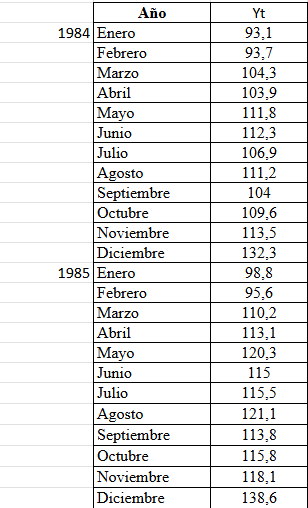
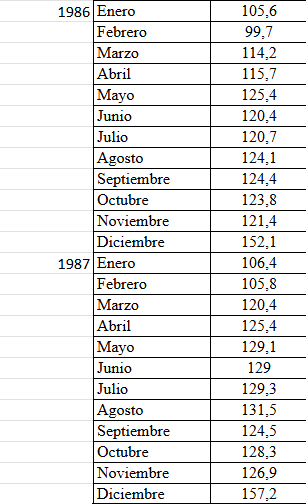

In [2]:
serie = [93.1, 93.7, 104.3, 103.9, 111.8, 112.3, 106.9, 111.2, 104.0, 109.6, 113.5, 132.3,98.8, 95.6, 110.2, 113.1, 120.3, 115.0, 115.5, 121.1, 113.8, 115.8, 118.1, 138.6,105.6, 99.7, 114.2, 115.7, 125.4, 120.4, 120.7, 124.1, 124.4, 123.8, 121.4, 152.1,106.4, 105.8, 120.4, 125.4, 129.1, 129.0, 129.3, 131.5, 124.5, 128.3, 126.9, 157.2]

In [3]:
def mostrar_ac(data,alfa):
    plt.rc("figure", figsize=(10,6))

    #funcion de autocorrelacion y ploteo
    plot_acf(data, lags=12,alpha=alfa,bartlett_confint=False)

    plt.ylim(-1,1)
    plt.xlabel('lags', fontsize=10)
    plt.ylabel('Correlacion', fontsize=10)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.title(' Ploteo de Autocorrelacion', fontsize=7)
    plt.tight_layout()
    plt.show()


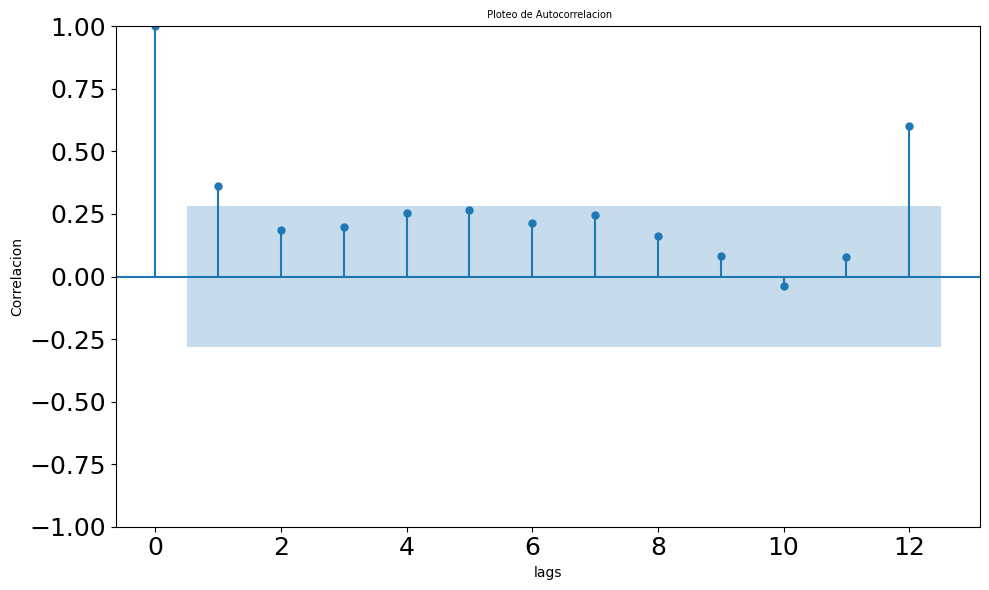

In [4]:
mostrar_ac(serie,0.05)

In [5]:
#data= serie de tiepo
#alfa= coeficiente de atenuacion datos
#beta = coeficiente de atenuacion tendencia
#gama = coeficiente de atenuacion estacionalidad
#s = periodo (12 para el año, 4 = trimestre)
def holt_winters(data, alfa, beta, gamma, s):
    series = pd.Series(data)
    n = len(series)

    # Inicialización de vectores
    A = pd.Series(np.zeros(n))
    T = pd.Series(np.zeros(n))
    S = pd.Series(np.ones(n))
    y_hat = pd.Series([np.nan] * n)
    A.iloc[0] = series.iloc[0] 
    for t in range(1, n):

        if t >= s:
            S_prev = S.iloc[t - s]
        else:
            S_prev = 1

        A.iloc[t] = alfa * (series.iloc[t] / S_prev) + (1 - alfa) * (A.iloc[t-1] + T.iloc[t-1])

        T.iloc[t] = beta * (A.iloc[t] - A.iloc[t-1]) + (1 - beta) * T.iloc[t-1]
        
        if t>=s:
            S.iloc[t] = gamma * (series.iloc[t] / A.iloc[t]) + (1 - gamma) * S_prev
            #pronostico
            y_hat.iloc[t] = (A.iloc[t-1] + T.iloc[t-1]) * S_prev
            

    pronostico = (A.iloc[-1] + T.iloc[-1]) * S.iloc[n - s]
    resultado = pd.concat([y_hat, pd.Series([pronostico])], ignore_index=True)
    return resultado

In [6]:
P = holt_winters(serie,0.1,0.1,0.45,12)
print(P)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
5            NaN
6            NaN
7            NaN
8            NaN
9            NaN
10           NaN
11           NaN
12    110.268515
13    110.124641
14    109.529908
15    110.461350
16    111.616034
17    113.462089
18    114.608918
19    115.699974
20    117.295925
21    117.967322
22    118.749906
23    119.677733
24    117.527077
25    115.929297
26    122.035253
27    122.935103
28    125.587052
29    123.167071
30    123.313854
31    125.667915
32    122.359042
33    123.821171
34    125.156541
35    133.630584
36    117.706776
37    113.870583
38    124.407064
39    125.734146
40    132.047386
41    127.896947
42    128.319569
43    131.453124
44    129.533652
45    129.262607
46    128.762535
47    146.868124
48    116.746033
dtype: float64


# Metodo de descomposición

El método de descomposición (o decomposition forecasting method) es una técnica clásica en series de tiempo que consiste en separar los datos en varios componentes básicos para luego analizarlos y combinarlos para hacer un pronóstico.

$$ \hat{y}_{t}=T_{t}*S_{t}*C_{t}*I_{t}$$
Donde :

$T_{t}$ = comportamiento a largo plazo. (Tendencia del conjunto de datos) (Formula de pronostico)

$S_{t}$ = Estimación de la Estacionalidad

$C_{t}$ = Ciclo o fluctuaciones largas

$I_{t}$ = Aleatoriedad (S varia en torno a 1. mientras más lejano a 1 es. exiten factores externos que hacer varian.)


Donde :

$T_{t}$ = Responde preguntas como ¿Sube o baja la serie con el tiempo? ¿Hay crecimiento "natural" por el paso del tiempo?

$S_{t}$ = Son patrones repetitivos que se repiten cada s periodos (meses, trimestres, semanas). 

Si $S_{t}$ > 1 , se entiende que hay un crecimiento en ese periodo. Si $S_{t}$ < 1 existe un decrecimiento en ese periodo.

$C_{t}$ = Ciclo o fluctuaciones largas (en 5 años a 10 años), determina el nivel de recesion y expansion del comportamiento de los datos.
 

Para calcular $T_{t}$ se puede aplicar regresion lineal.

Para calcular $S_{t}$ Se obtiene de la siguiente manera:

$$ S_{t}=\frac{Y_{t}}{P_{t}}$$

Donde :
$P_{t}$ = promedio movil simple un periodo L (mensual, semestral, etc ) (En algunos casos se ocupa un promedio movil distinto. Como es el promedio movil centrado)

$$P_{t} = \frac{Y_{t-n/2}+ Y_{t-(n/2) +1 }... + Y_{t+ (n/2)} }{n} $$


Cuando n es par → hay que centrar con promedio de promedios.

$$P'_{t} = \frac{P_{t}+P_{t-1}}{2n}$$

Para encontrar el factor de estacionalidad ($S_{t} (IE)$). Necesitamos promediar cada $P'_{t}$ por cada periodo estacional (ejemplo: todos los eneros, febreros, etc.).


$$S_{j} = prom (\frac{Y_{t}}{P'_{t}})$$

Tomando en cuenta el ejemplo anterior quedaria asi :

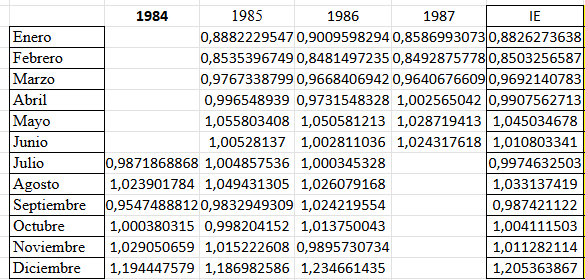

Para comprobar que cada periodo esta correcto $\sum IE_{t} \approx n $

Se puede ajustar esos valores multiplicando por un factor K

$$K = \frac{n}{\sum IE_{t}}$$

$$IEA_{t} = IE_{t}*k $$

Esto elimina acumulación o sesgo.

Por lo que la predicion seria

$$ \hat{y}_{t} = T_{t} * IEA_{t}$$



Para calcular $C_{t}$ :
$$C_{t} * I_{t} = \frac{Y_{t}}{T_{t}*S_{t}}$$


Les recomiendo ver el excel para ver ejemplo